## Project Template

In [135]:
#Demographic features: Age at Diagnosis, Year of Diagnosis, Sex, Race, Ethnicity
#Clinical features: primary cancer site, tumor grade, summary stage
#Socioeconomic features:Marital Status, Transportation, Appalachia

## AUROC Plots: FPR, TPR, Threshold

In [137]:
def generate_auc_roc_curve(model, X_test, y_true):
    y_pred = model.predict_proba(X_test)[:,1]
    fpr, tpr, threshold = roc_curve(y_true, y_pred)
    auc = roc_auc_score(y_true, y_pred)
    auc_t = round(auc,3)
    return fpr, tpr, threshold, auc_t

## Bootstrapping by resampling method 

In [ ]:
from sklearn.utils import resample
rng_seed = 42  # control reproducibility

#build confusion matrix with boostrapping by resampling
def confmat(clf, X_test, y_test, n_iter):
    tnr, tpr, ppv, npv = ResetList(n_iter)
    for i in range(n_iter):
        # bootstrap by sampling with replacement on the prediction indices
        X_test_resample, y_test_resample = resample(X_test, y_test)
        clf.fit(X_test_resample, y_test_resample)
        y_pred_resample = clf.predict(X_test_resample)
        tn, fp, fn, tp = metrics.confusion_matrix(y_test_resample, y_pred_resample, labels=[0,1]).ravel()
        #print ("metrics: {}, {}, {}, {} " .format(tn, fp, fn, tp))
        #sensitivity
        sensitivity = tp/(tp+fn)
        tpr[i]=sensitivity
        #print ("tpr: {}, {}" .format(i, sensitivity))
    
        #specificity
        specificity = tn/(tn+fp)
        tnr[i]=specificity
        
        #precision
        precision = tp/(tp+fp)
        ppv[i]=precision
        
        #Negative predictive value
        negative_pv = tn/(tn+fn)
        npv[i]=negative_pv
        #print (npv) 
    return tnr, tpr, ppv, npv

## Confidence Intervals 

In [ ]:
#cacluate metrics and confidence intervals
def confmat_metrics (confusion_metric):
    sorted_metric = np.array(confusion_metric)   
    sorted_metric.sort()

    #confidence interval 95: [0.025 - 0.975]
    ci_lower = sorted_metric[int(0.025 * len(sorted_metric))]
    ci_upper = sorted_metric[int(0.975 * len(sorted_metric))]
    #print("Confidence interval: [{} - {}]".format(round(ci_lower,3), round(ci_upper,3)))
    return ci_lower, ci_upper 

### Divide Data into Appalachia and Non-Appalachia records

In [ ]:
data_A = 
data_NA = 

### Standardize and Scale the feature data: Appalachia

In [181]:
#Standardize and Scale the Feature Data:Appalachia
from sklearn.preprocessing import StandardScaler
ss_a=StandardScaler()
ss_a.fit_transform(data_A.drop(['Survival_Recode'], axis=1))
scaled_data=ss_a.transform(data_A.drop(['Survival_Recode'], axis=1))
scaled_df=pd.DataFrame(scaled_data, columns=data_A.columns[:-1])

In [182]:
#setup X and y
X_A = scaled_df.drop(['Survival_Recode'], axis=1)
y_A=data_A['Survival_Recode']

### Standardize and scale the feature data: non-Appalachia

In [184]:
from sklearn.preprocessing import StandardScaler
ss_na=StandardScaler()
ss_na.fit_transform(------)
scaled_data_NA = -------
scaled_df_NA= ------

In [186]:
#setup X and y
X_NA = scaled_df_NA.drop(['Survival_Recode'], axis=1)
y_NA=data_NA['Survival_Recode']

### Appalachia: Split Data into Train, Test, and Validate: 70-20-10

### Build Model: Applachia

#### model:
    ### Model1: Logistic Regression: Pick a model and justify: Options: Newton-CG, liblinear, lbfgs
    ### Model2: XGboost: Try default and hyperparametrized models  

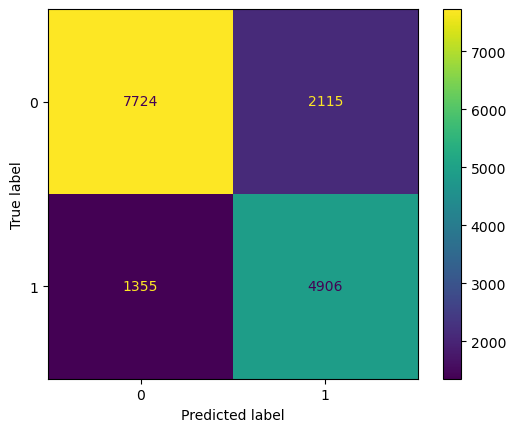

In [197]:
#Appalachia: confusion matrix
cm_a = metrics.confusion_matrix(yA_test, yA_test_pred)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = cm_a)
cm_display.plot()
plt.show()

### Appalachia: Hyperparametrization 

In [198]:
# Hyper-parameter grid for XGBoost
params = {
        'min_child_weight': [1, 3, 5, 7, 9, 10],
        'gamma': [0, 0.3, 0.5, 1, 1.2, 1.5, 2, 3, 4, 5],
        'subsample': [0.4, 0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
        'colsample_bylevel': [0.6, 0.8, 1.0],
        'colsample_bynode':[0.5, 1.0],
        'max_depth': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
        'reg_alpha': [0.0, 2.0, 5.0, 7.0, 10.0],
        'gamma':[0.0, 2.0, 4.0, 6.0, 8.0, 10.0],
        'n_estimators': [100, 200, 300, 400, 500, 600, 800, 900, 1000],
        'learning_rate': [0.0001, 0.001, 0.01, 0.1, 0.2, 0.3]
        }

In [230]:
#optimize xgboost
opt_A = xgb.XGBClassifier()

In [1]:
##Appalachia 5-fold cross validation

In [231]:
folds = 5
param_comb = 5

skf = StratifiedKFold(n_splits=folds, shuffle = True, random_state = 1001)

random_search = RandomizedSearchCV(xgbopt, param_distributions=params, n_iter=param_comb, scoring='roc_auc', n_jobs=4, cv=skf.split(XA_train,yA_train), 
                                   verbose=3, random_state=1001 )
# Here we go
random_search.fit(XA_train, yA_train)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


RandomizedSearchCV(cv=<generator object _BaseKFold.split at 0x0000018CC02ACF20>,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           gamma=None, grow_policy=None,
                                           importance_...
                                        'colsample_bytree': [0.6, 0.8, 1.0],
                                        'gamma': [0.0, 2.0, 4.0, 6.0, 8.0,
                                                  10.0],
                                        'learning_rate': [0.0001, 0.001, 0.01,
                                                          0.1, 0.2, 0.3],
                                        'max_depth': [2, 3, 4, 5, 6, 7, 8, 9,
                                                      10, 11, 12],
                                        'min_child_weight': [1, 3, 5, 7, 9, 10],
                                        'n_estimators': [100, 200, 300, 400,
                                                         500, 600, 800, 900,
                                                         1000],
                                        'reg_alpha': [0.0, 2.0, 5.0, 7.0, 10.0],
                                        'subsample': [0.4, 0.6, 0.8, 1.0]},
                   random_state=1001, scoring='roc_auc', verbose=3)

### Appalachia: XGB Optimized with Hyperparametrization

In [232]:
xgboptimized_A = xgb.XGBClassifier("insert hyperparameters")

In [233]:
xgboptimized_A.fit(XA_train, yA_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=1.0, colsample_bynode=0.5, colsample_bytree=0.8,
              device=None, early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, gamma=10.0,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.3, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=7, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [234]:
#Appalachia predicted
yA_test_pred = xgboptimized_A.predict(XA_test)

In [235]:
round(xgboptimized_A.score(XA_test, yA_test),3)

0.784

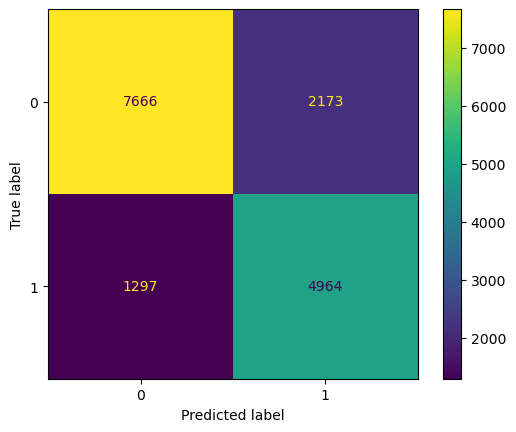

In [236]:
#Appalachia: confusion matrix
cm_a = metrics.confusion_matrix(yA_test, yA_test_pred)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = cm_a)
cm_display.plot()
plt.show()

### Build Model: Non-Appalachia

In [2]:
##Repeat steps in Appalachia computation 

### Calculate Bias between Appalachia and non-Applachia ML Models using Desparate Impact Ratio

### Plot AUROC for Appalachia, Non-Appalachia, and Baseline

In [3]:
#ROC Curve: Appalachia, non-appalachia, and baseline
AUROC metrics for Appalachia = generate_auc_roc_curve(xgboptimized_A, XA_test, yA_test)
fpr_na, tpr_na, threshold_na, auc_na = generate_auc_roc_curve(xgboptimized_NA, XNA_test, yNA_test)

#baseline
fpr_b = [0, 0.5, 1.]
tpr_b = [0, 0.5, 1.]

SyntaxError: invalid syntax (4235341816.py, line 2)

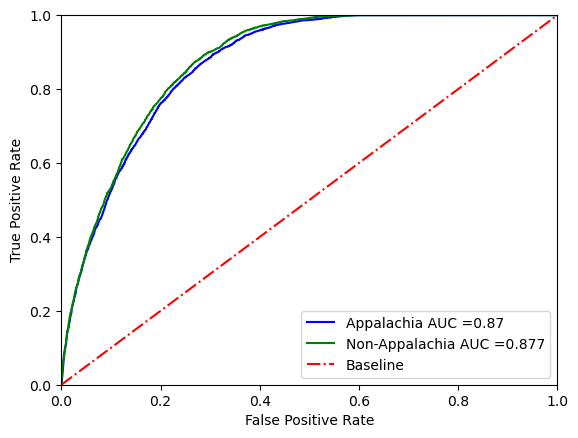

In [269]:
plt.plot(fpr_a, tpr_a, label="Appalachia AUC =" +str(auc_a), linewidth=1.5, color='b')
plt.plot(fpr_na, tpr_na, label="Non-Appalachia AUC =" +str(auc_na), linewidth=1.5, color='g')
plt.plot(fpr_b, tpr_b, label="Baseline", linestyle='dashdot', linewidth=1.5, color='r')
plt.xlim(0.0,1.0)
plt.ylim(0.0,1.0)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc=4)
plt.show()

### Appalachia: AUROC scores by boostrap and replace samples

In [272]:
n_bootstraps = 10
rng_seed = 42  # control reproducibility
def bootstrap(model, X_test, y_true):
    rng = np.random.RandomState(42)
    b_scores = []
    y_pred = clf.predict_proba(X_test)[:,1]
    for i in range(n_bootstraps):
        # bootstrap by sampling with replacement on the prediction indices
        indices = rng.randint(0, len(y_pred), len(y_pred))
        score = roc_auc_score(y_true[indices], y_pred[indices])
        b_scores.append(score)
        #print("Bootstrap #{} ROC area: {:0.3f}".format(i + 1, score))
    return b_scores

In [274]:
#get a list of booststrap scores
b_scores_a = bootstrap(xgboptimized_A, XA_test, yA_true)

In [275]:
#Mean of the histogram
import statistics as sm
mean_value_a = sm.mean(b_scores_a)
print ("Mean =", round(mean_value_a,3))

Mean = 0.87


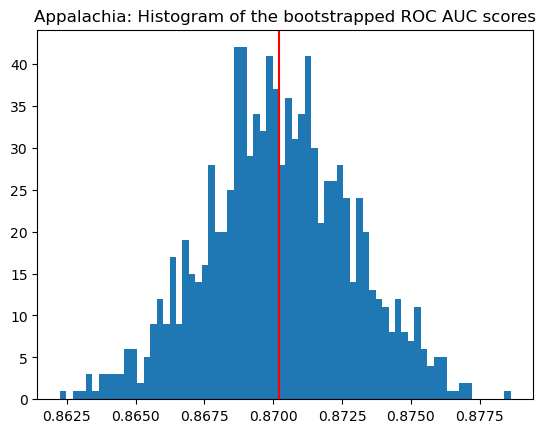

In [276]:
import matplotlib.pyplot as plt
plt.hist(b_scores_a, bins=70)
plt.title('Appalachia: Histogram of the bootstrapped ROC AUC scores')
#show the line on historgram for Median value
plt.axvline(x=mean_value_a, color='r')
plt.show()

In [277]:
#compute confidence interval for AUROC 
sorted_scores = np.array(b_scores_a)
sorted_scores.sort()

# Computing the lower and upper bound of the 95% confidence interval
ci_lower_auroc = sorted_scores[int(0.025 * len(sorted_scores))]
ci_upper_auroc = sorted_scores[int(0.975 * len(sorted_scores))]
print("Appalachia: Confidence interval for AUROC: [{:0.3f} - {:0.3}]".format(ci_lower_auroc, ci_upper_auroc))

Appalachia: Confidence interval for AUROC: [0.865 - 0.875]


### Non-Appalachia: AUROC scores by boostrap and replace samples

In [282]:
#compute confidence interval for AUROC 
sorted_scores = np.array(b_scores_na)
sorted_scores.sort()

# Computing the lower and upper bound of the 95% confidence interval
ci_lower_auroc = sorted_scores[int(0.025 * len(sorted_scores))]
ci_upper_auroc = sorted_scores[int(0.975 * len(sorted_scores))]
print("Non-Appalachia: Confidence interval for AUROC: [{:0.3f} - {:0.3}]".format(ci_lower_auroc, ci_upper_auroc))

Non-Appalachia: Confidence interval for AUROC: [0.871 - 0.882]


### Appalachia: Metrics

In [430]:
#Appalachia: calculate metrics across the entire resampled data and report CI for all 4 metrics
n_iter=1000
tnr_a, tpr_a, ppv_a, npv_a = confmat(xgboptimized_A, XA_test, yA_test, n_iter)

In [409]:
low, high = confmat_metrics(tpr_a)
print ("Bootstrap {}: Sensitivity(TPR):{} and the CI: [{} - {}]" .format(n_iter, round(np.mean(tpr_a),3), round(low,3), round(high,3)))
low, high = confmat_metrics(tnr_a)
print ("Bootstrap {}: Specificity(TNR):{} and the CI: [{} - {}]" .format(n_iter, round(np.mean(tnr_a),3), round(low,3), round(high,3)))
low, high = confmat_metrics(ppv_a)
print ("Bootstrap {}: Precision(PPV):{} and the CI: [{} - {}]" .format(n_iter, round(np.mean(ppv_a),3), round(low,3), round(high,3)))
low, high = confmat_metrics(npv_a)
print ("Bootstrap {}: NPV:{} and the CI: [{} - {}]" .format(n_iter, round(np.mean(npv_a),3), round(low,3), round(high,3)))

Bootstrap 1000: Sensitivity(TPR):0.793 and the CI: [0.77 - 0.815]
Bootstrap 1000: Specificity(TNR):0.781 and the CI: [0.765 - 0.795]
Bootstrap 1000: Precision(PPV):0.698 and the CI: [0.686 - 0.708]
Bootstrap 1000: NPV:0.856 and the CI: [0.845 - 0.867]


### Non-Appalachia: Metrics

In [411]:
#Non-Appalachia: Calculate metrics across the entire resampled data and report CI for all 4 metrics
n_iter=1000
tnr_na, tpr_na, ppv_na, npv_na = confmat(xgboptimized_NA, XNA_test, yNA_test, n_iter)

In [412]:
low, high = confmat_metrics(tpr_na)
print ("Bootstrap {}: Sensitivity(TPR):{} and the CI: [{} - {}]" .format(n_iter, round(np.mean(tpr_na),3), round(low,3), round(high,3)))
low, high = confmat_metrics(tnr_na)
print ("Bootstrap {}: Specificity(TNR):{} and the CI: [{} - {}]" .format(n_iter, round(np.mean(tnr_na),3), round(low,3), round(high,3)))
low, high = confmat_metrics(ppv_na)
print ("Bootstrap {}: Precision(PPV):{} and the CI: [{} - {}]" .format(n_iter, round(np.mean(ppv_na),3), round(low,3), round(high,3)))
low, high = confmat_metrics(npv_na)
print ("Bootstrap {}: NPV:{} and the CI: [{} - {}]" .format(n_iter, round(np.mean(npv_na),3), round(low,3), round(high,3)))

Bootstrap 1000: Sensitivity(TPR):0.807 and the CI: [0.783 - 0.833]
Bootstrap 1000: Specificity(TNR):0.78 and the CI: [0.763 - 0.798]
Bootstrap 1000: Precision(PPV):0.696 and the CI: [0.683 - 0.709]
Bootstrap 1000: NPV:0.867 and the CI: [0.854 - 0.879]


### P-value computation

In [433]:
#Calculate t-score
def calculate_t_score(sample1, sample2):
    mean1 = np.mean(sample1)
    mean2 = np.mean(sample2)
    std1 = np.std(sample1, ddof=1) 
    std2 = np.std(sample2, ddof=1)
    n1 = len(sample1)
    n2 = len(sample2)
    t_score = (mean1 - mean2) / np.sqrt((std1**2 / n1) + (std2**2 / n2))
    return t_score

# Step 2: Determine the degrees of freedom (df)
def calculate_degrees_of_freedom(sample1, sample2):
    n1 = len(sample1)
    n2 = len(sample2)
    df = n1 + n2 - 2  # For a two-sample t-test
    return df

# Step 3: Identify the appropriate t-distribution
# (The scipy.stats.t distribution is used, which automatically considers the degrees of freedom)
 
# Step 4: Find the p-value
def calculate_p_value(t_score, df):
    p_value = 2 * (1 - t.cdf(np.abs(t_score), df))
    return p_value
 
# Step 5: Interpret the p-value
def interpret_p_value(p_value, alpha=0.05):
    if p_value < alpha:
        return "Reject the null hypothesis. There is a statistically significant difference."
    else:
        return "Fail to reject the null hypothesis. There is no statistically significant difference."

In [434]:
# pick two samples:Appalachia and non-Appalachia
#ROC Scores
t_score = calculate_t_score(b_scores_a, b_scores_na)
df = calculate_degrees_of_freedom(b_scores_a, b_scores_na)
p_value = calculate_p_value(t_score, df)
result = interpret_p_value(p_value)
 
print("p-value:", p_value)
print(result)

p-value: 0.0
Reject the null hypothesis. There is a statistically significant difference.


In [435]:
# pick two samples:Appalachia and non-Appalachia
#TPR


p-value: 0.0
Reject the null hypothesis. There is a statistically significant difference.


In [436]:
# pick two samples:Appalachia and non-Appalachia
#TNR

 
print("p-value:", p_value)
print(result)

p-value: 0.013536729614925358
Reject the null hypothesis. There is a statistically significant difference.


In [437]:
# pick two samples:Appalachia and non-Appalachia
#PPV

 
print("p-value:", p_value)
print(result)

p-value: 4.6230619332732203e-10
Reject the null hypothesis. There is a statistically significant difference.


In [438]:
#NPV


p-value: 0.0
Reject the null hypothesis. There is a statistically significant difference.


## Model Validation: Appalachia

In [4]:
#Appalachia : Calculate metrics across the entire resampled data and report CI for all 4 metrics
n_iter=1000
tnr_va, tpr_va, ppv_va, npv_va = confmat(xgboptimized, XA_valid, yA_valid, n_iter)

NameError: name 'confmat' is not defined

In [264]:
low, high = confmat_metrics(tpr_va)
print ("Validation-A: Bootstrap {}: Sensitivity(TPR):{} and the CI: [{} - {}]" .format(n_iter, round(np.mean(tpr_va),3), round(low,3), round(high,3)))
low, high = confmat_metrics(tnr_va)
print ("Validation-A: Bootstrap {}: Specificity(TNR):{} and the CI: [{} - {}]" .format(n_iter, round(np.mean(tnr_va),3), round(low,3), round(high,3)))
low, high = confmat_metrics(ppv_va)
print ("Validation-A: Bootstrap {}: Precision(PPV):{} and the CI: [{} - {}]" .format(n_iter, round(np.mean(ppv_va),3), round(low,3), round(high,3)))
low, high = confmat_metrics(npv_va)
print ("Validation-A: Bootstrap {}: NPV:{} and the CI: [{} - {}]" .format(n_iter, round(np.mean(npv_va),3), round(low,3), round(high,3)))

Validation-A: Bootstrap 1000: Sensitivity(TPR):0.805 and the CI: [0.762 - 0.879]
Validation-A: Bootstrap 1000: Specificity(TNR):0.779 and the CI: [0.734 - 0.8]
Validation-A: Bootstrap 1000: Precision(PPV):0.703 and the CI: [0.689 - 0.73]
Validation-A: Bootstrap 1000: NPV:0.861 and the CI: [0.84 - 0.899]


#### Non-Appalachia

In [266]:
#Non-Appalachia : Calculate metrics across the entire resampled data and report CI for all 4 metrics
n_iter=1000
----------------- = confmat(xgboptimized_NA, XNA_valid, yNA_valid, n_iter)

In [267]:
low, high = confmat_metrics(tpr_vna)
print ("Validation-NA: Bootstrap {}: Sensitivity(TPR):{} and the CI: [{} - {}]" .format(n_iter, round(np.mean(tpr_vna),3), round(low,3), round(high,3)))
low, high = confmat_metrics(tnr_vna)
print ("Validation-NA: Bootstrap {}: Specificity(TNR):{} and the CI: [{} - {}]" .format(n_iter, round(np.mean(tnr_vna),3), round(low,3), round(high,3)))
low, high = confmat_metrics(ppv_vna)
print ("Validation-NA: Bootstrap {}: Precision(PPV):{} and the CI: [{} - {}]" .format(n_iter, round(np.mean(ppv_vna),3), round(low,3), round(high,3)))
low, high = confmat_metrics(npv_vna)
print ("Validation-NA: Bootstrap {}: NPV:{} and the CI: [{} - {}]" .format(n_iter, round(np.mean(npv_vna),3), round(low,3), round(high,3)))

Validation-NA: Bootstrap 1000: Sensitivity(TPR):0.776 and the CI: [0.628 - 0.876]
Validation-NA: Bootstrap 1000: Specificity(TNR):0.793 and the CI: [0.74 - 0.864]
Validation-NA: Bootstrap 1000: Precision(PPV):0.705 and the CI: [0.683 - 0.737]
Validation-NA: Bootstrap 1000: NPV:0.851 and the CI: [0.8 - 0.896]


## SHAP Plots

### Appalachia

In [268]:
import shap
Xd = xgb.DMatrix(XA_valid, label=yA_valid)
model = xgb.train({"eta":0.3, "max_depth":10, "base_score":0.5, "lambda":0},Xd,1000)

In [269]:
modelpredict = model.predict(Xd)
model_error = np.linalg.norm(yA_valid - modelpredict)
print("Model error =", round(model_error,3))

Model error = 1.921


In [270]:
#print(model.get_dump(with_stats=True)[0])

In [271]:
explainer = shap.TreeExplainer(model)
explanation = explainer(Xd)
shap_values = explanation.values

In [277]:
# make sure the SHAP values add up to marginal predictions. Should be Zero
print(round(np.abs(shap_values.sum(axis=1)
                  + explanation.base_values - np.array(yA_valid)).max(),2))

0.67


In [278]:
#print(explanation.data)
explanation.data = XA_valid

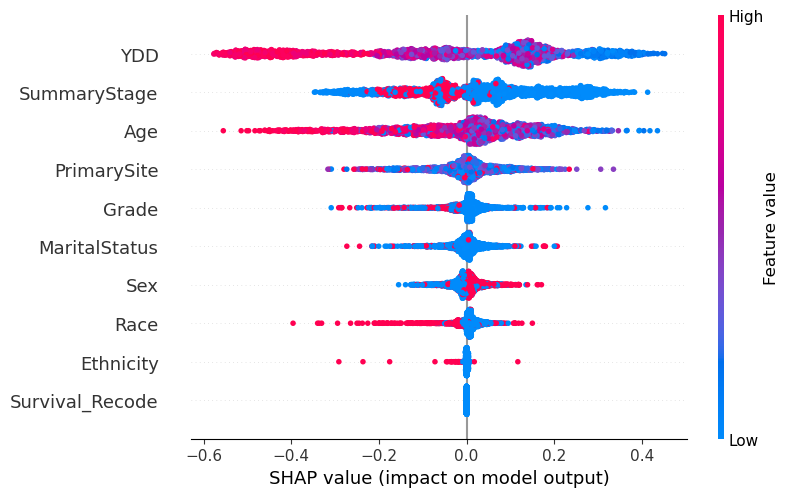

In [279]:
shap.plots.beeswarm(explanation)

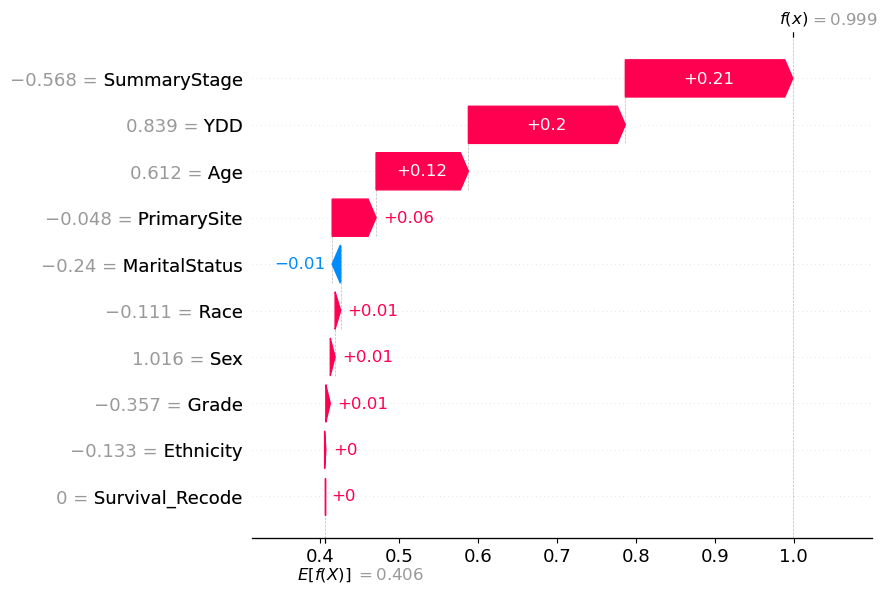

In [280]:
shap.plots.waterfall(explanation[1])

## Non-Appalachia

In [ ]:
#Assignment 